In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from statsmodels.stats.proportion import proportions_ztest
import statsmodels.tools.tools as stattools
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix
import statsmodels.api as sm
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score

In [2]:
insurance_df = pd.read_csv('../01_data/raw_full.csv')

In [3]:
insurance_df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [4]:
insurance_df['Response'].value_counts() 

Response
0    334399
1     46710
Name: count, dtype: int64

In [5]:
df = insurance_df.copy()

In [6]:
# manual ordinal encoding
df['Vehicle_Age'] = df['Vehicle_Age'].map({'< 1 Year': 0, '1-2 Year': 1, '> 2 Years': 2})

# log transformation for Annual_Premium
df['Annual_Premium_Log'] = np.log1p(df['Annual_Premium'])

# one dummy encoding

df = pd.get_dummies(df, columns = ['Gender', 'Vehicle_Damage', 'Policy_Sales_Channel'], drop_first = True)


In [7]:
df.head(2)

,id,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Annual_Premium,Vintage,Response,Annual_Premium_Log,...,Policy_Sales_Channel_152.0,Policy_Sales_Channel_153.0,Policy_Sales_Channel_154.0,Policy_Sales_Channel_155.0,Policy_Sales_Channel_156.0,Policy_Sales_Channel_157.0,Policy_Sales_Channel_158.0,Policy_Sales_Channel_159.0,Policy_Sales_Channel_160.0,Policy_Sales_Channel_163.0
0,1,44,1,28.0,0,2,40454.0,217,1,10.607946,...,False,False,False,False,False,False,False,False,False,False
1,2,76,1,3.0,0,1,33536.0,183,0,10.420405,...,False,False,False,False,False,False,False,False,False,False


## Test 1
Dropping: `Driving_License`, `Region_Code`, `Vintage`   
Encoded: `Gender`, `Vehicle_Damage`, `Policy_Sales_Channel`, `Vehicle_Age`  
Log Transform: `Annual_Premium`

In [8]:
df = df.drop( columns = ['id','Driving_License', 'Region_Code', 'Vintage', 'Annual_Premium'])

In [9]:
X = df.drop(columns=['Response'])
y = df['Response']

In [10]:
X_train, X_test, y_train, y_test = train_test_split( 
    X, y, test_size = 0.2, random_state = 42)

### Decsion Tree

In [11]:
# class_weight 'balanced' reweights the loss so the minority class
dt= DecisionTreeClassifier(criterion = 'entropy', max_leaf_nodes = 5, class_weight= 'balanced', random_state = 42).fit(X_train, y_train)

In [12]:
# model's predictions
y_pred = dt.predict(X_test)

In [13]:
#model's estimated probability that each sample belongs to each class
y_proba = dt.predict_proba(X_test)[:,1]
y_proba

array([0.00625051, 0.76113241, 0.76113241, ..., 0.00625051, 0.00625051,
       0.00625051], shape=(76222,))

In [14]:
# confusion matrix
cm_dt = confusion_matrix(y_test, y_pred)
cm_dt_df = pd.DataFrame(
    cm_dt, index=['Actual 0', 'Actual 1'], columns = ['Predicted  0', 'Predicted 1'])
cm_dt_df

,Predicted 0,Predicted 1
Actual 0,45896,20803
Actual 1,1053,8470


In [15]:
print('Decision Tree Metrics')
print('---------------------------------------------------------')
print(classification_report(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_proba))
print('AUC-PR:', average_precision_score(y_test, y_proba))

Decision Tree Metrics
---------------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.69      0.81     66699
           1       0.29      0.89      0.44      9523

    accuracy                           0.71     76222
   macro avg       0.63      0.79      0.62     76222
weighted avg       0.89      0.71      0.76     76222

ROC-AUC: 0.8334927375407218
AUC-PR: 0.30626328071891784


In [16]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

Compute precision-recall pairs for different probability thresholds. Returns precsin, recall and thresholds
[sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html)

In [17]:
# compute average precision is the area under the pr curve
ap_score = average_precision_score(y_test, y_proba)

`average_precision_score`: Compute average precision (AP) from prediction scores.
AP summarizes a precision-recall curve as the weighted mean of precisions achieved at each threshold, with the increase in recall from the previous threshold used as the weight.
[sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html)

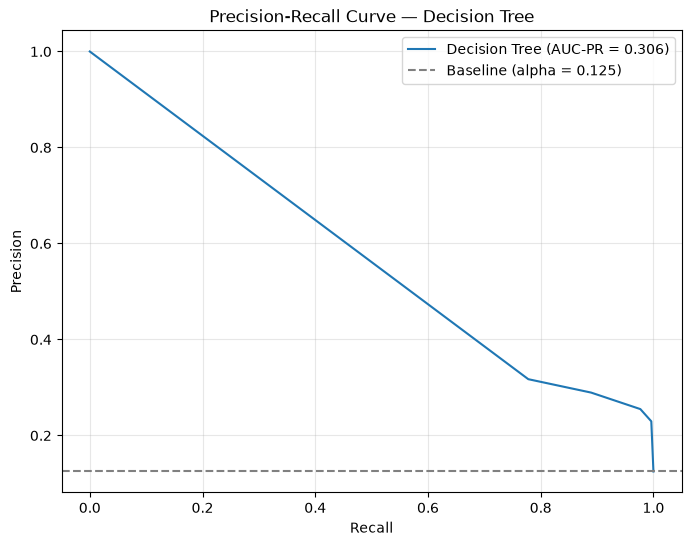

In [18]:
#plot PR curve
plt.figure(figsize=(8, 6))

plt.plot(recall, precision, label=f'Decision Tree (AUC-PR = {ap_score:.3f})')

# Baseline is the expected precision of a random classifier
# also baseline is the proportion of postive cases: alpha
baseline = y_test.sum() / len(y_test)

plt.axhline(y=baseline, color='grey', linestyle='--', label=f'Baseline (alpha = {baseline:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Decision Tree')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Logistic Regression

In [19]:
#scaling
continuous_features = ['Age', 'Annual_Premium_Log']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])

`class_weight='balanced'` automatically assigns higher penalties to mistakes made on rare classes and lower penalties to frequent ones. It uses the formula n_samples / (n_classes * class_count) to equalize the total impact of each class during training


In [20]:
# fitting logistic regression on scaled featurs
lr =LogisticRegression(class_weight = 'balanced', max_iter = 1000, random_state =42).fit(X_train_scaled, y_train)

In [21]:
#prediction 
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:,1]

In [22]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_lr_df = pd.DataFrame(
    cm_lr, index=['Actual No', 'Actual Yes'], columns = ['Predicted  No', 'Predicted Yes'])
cm_lr_df

,Predicted No,Predicted Yes
Actual No,42524,24175
Actual Yes,519,9004


In [23]:
print('Logistic Regression')
print('---------------------------------------------------------')
print(classification_report(y_test, y_pred_lr))
print('ROC-AUC:', roc_auc_score(y_test, y_proba_lr))
print('AUC-PR:', average_precision_score(y_test, y_proba_lr))

Logistic Regression
---------------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      0.64      0.77     66699
           1       0.27      0.95      0.42      9523

    accuracy                           0.68     76222
   macro avg       0.63      0.79      0.60     76222
weighted avg       0.90      0.68      0.73     76222

ROC-AUC: 0.8490212526248512
AUC-PR: 0.3375649559296739


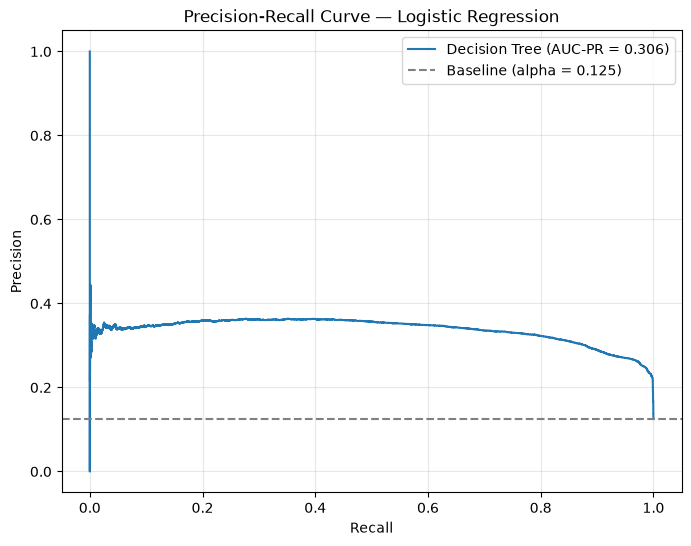

In [24]:
precision_lr, recall_lr, thresholds_lr = precision_recall_curve(y_test, y_proba_lr)
ap_score_lr = average_precision_score(y_test, y_proba_lr)
baseline = y_test.mean()


#plot PR curve
plt.figure(figsize=(8, 6))

plt.plot(recall_lr, precision_lr, label=f'Decision Tree (AUC-PR = {ap_score:.3f})')

plt.axhline(y=baseline, color='grey', linestyle='--', label=f'Baseline (alpha = {baseline:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Logistic Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Random Forest

In [25]:
# Fit a random forest
n_estimators = 200          
max_depth = 10   
class_weight = 'balanced'  

rf = RandomForestClassifier(
    n_estimators=n_estimators,
    max_depth=max_depth,
    class_weight=class_weight,
    random_state=42,         
    n_jobs=-1                
).fit(X_train, y_train)     

In [26]:
# generate predictions 
y_pred_rf = rf.predict(X_test)                  
y_proba_rf = rf.predict_proba(X_test)[:, 1]    

In [27]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_rf_df = pd.DataFrame(
    cm_rf, index=['Actual No', 'Actual Yes'], columns = ['Predicted  No', 'Predicted Yes'])
cm_rf_df

,Predicted No,Predicted Yes
Actual No,44359,22340
Actual Yes,656,8867


In [28]:
print('Random Forest')
print('---------------------------------------------------------')
print(confusion_matrix(y_test, y_pred_rf))
print('---------------------------------------------------------')
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print('AUC-PR:', average_precision_score(y_test, y_proba_rf))

Random Forest
---------------------------------------------------------
[[44359 22340]
 [  656  8867]]
---------------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      0.67      0.79     66699
           1       0.28      0.93      0.44      9523

    accuracy                           0.70     76222
   macro avg       0.63      0.80      0.61     76222
weighted avg       0.90      0.70      0.75     76222

ROC-AUC: 0.8542594668426096
AUC-PR: 0.3665062690255494


In [29]:
# Random forest feature importance reflects how much each feature reduces impurity
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

importance_df.head(20)

,Feature,Importance
5,Vehicle_Damage_Yes,0.361219
1,Previously_Insured,0.334353
0,Age,0.090821
150,Policy_Sales_Channel_152.0,0.073050
2,Vehicle_Age,0.053830
158,Policy_Sales_Channel_160.0,0.023038
29,Policy_Sales_Channel_26.0,0.017275
124,Policy_Sales_Channel_124.0,0.015684
3,Annual_Premium_Log,0.010051
155,Policy_Sales_Channel_157.0,0.004046


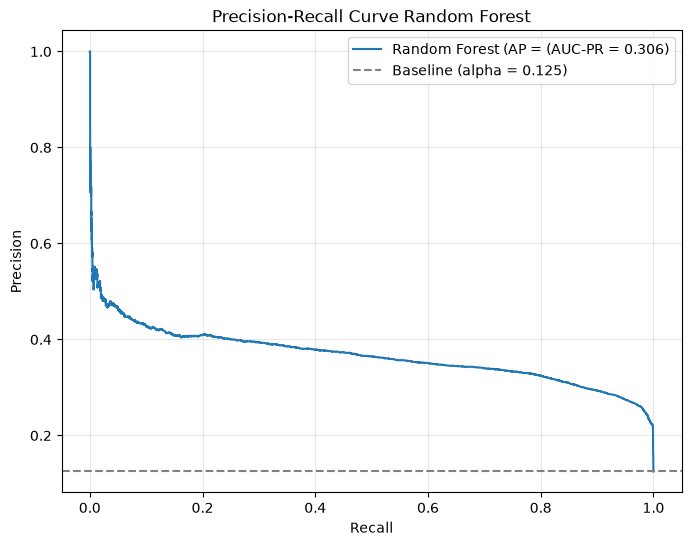

In [30]:
# Compute precision-recall curve and average precision for the random forest
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_proba_rf)
ap_score_rf = average_precision_score(y_test, y_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(recall_rf, precision_rf, label=f'Random Forest (AP = (AUC-PR = {ap_score:.3f})')

baseline = y_test.mean()
plt.axhline(y=baseline, color='gray', linestyle='--', label=f'Baseline (alpha = {baseline:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Random Forest')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Model Comparision

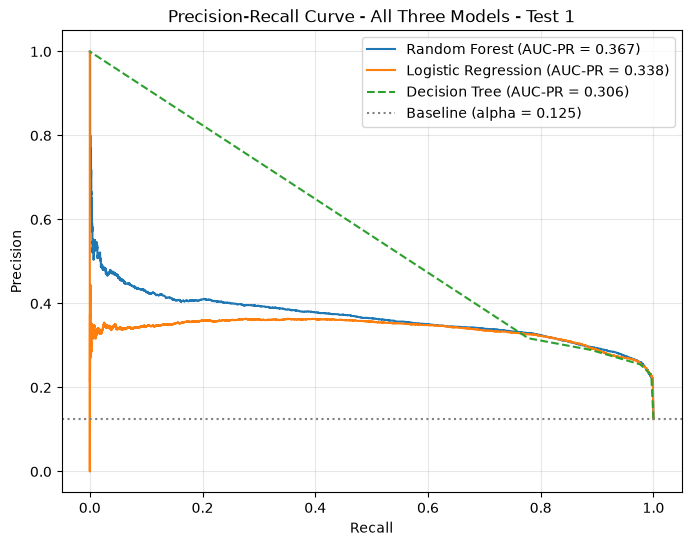

In [31]:
plt.figure(figsize=(8, 6))
plt.plot(recall_rf, precision_rf, label=f'Random Forest (AUC-PR = {ap_score_rf:.3f})')
plt.plot(recall_lr, precision_lr, label=f'Logistic Regression (AUC-PR = {ap_score_lr:.3f})')
plt.plot(recall, precision, label=f'Decision Tree (AUC-PR = {ap_score:.3f})', linestyle='--')

baseline = y_test.mean()
plt.axhline(y=baseline, color='gray', linestyle=':', label=f'Baseline (alpha = {baseline:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - All Three Models - Test 1')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Test 2
Dropping: `Driving_License`, `Vintage`   
Encoded: `Gender`, `Vehicle_Damage`, `Policy_Sales_Channel`, `Vehicle_Age`, `Region_Code'`  
Log Transform: `Annual_Premium`

In [32]:
df2 = insurance_df.copy()

In [33]:
# manual ordinal encoding
df2['Vehicle_Age'] = df2['Vehicle_Age'].map({'< 1 Year': 0, '1-2 Year': 1, '> 2 Years': 2})

# log transformation for Annual_Premium
df2['Annual_Premium_Log'] = np.log1p(df2['Annual_Premium'])

# one dummy encoding
df2 = pd.get_dummies(df2, columns = ['Gender', 'Vehicle_Damage', 'Policy_Sales_Channel', 'Region_Code'], drop_first = True)


In [34]:
df2 = df2.drop(
    columns=['Driving_License', 'Vintage','Annual_Premium', 'id'])

In [35]:
X = df2.drop(columns=['Response'])
y = df2['Response']

In [36]:
X_train2, X_test2, y_train2, y_test2 = train_test_split( 
    X, y, test_size = 0.2, random_state = 42)

### Decision Tree

In [37]:
# class_weight 'balanced' reweights the loss so the minority class
dt2= DecisionTreeClassifier(criterion = 'entropy', max_leaf_nodes = 5, class_weight= 'balanced', random_state = 42).fit(X_train2, y_train2)

In [38]:
y_pred2 = dt2.predict(X_test2)

In [39]:
y_proba2 = dt2.predict_proba(X_test2)[:,1]

In [40]:
cm_dt = confusion_matrix(y_test2, y_pred2)
cm_dt_df = pd.DataFrame(
    cm_dt, index=['Actual No', 'Actual Yes'], columns = ['Predicted  No', 'Predicted Yes'])
cm_dt_df

,Predicted No,Predicted Yes
Actual No,45896,20803
Actual Yes,1053,8470


In [41]:
print('Decision Tree')
print('---------------------------------------------------------')
print(classification_report(y_test2, y_pred2))
print('ROC-AUC:', roc_auc_score(y_test2, y_proba2))
print('AUC-PR:', average_precision_score(y_test2, y_proba2))

Decision Tree
---------------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.69      0.81     66699
           1       0.29      0.89      0.44      9523

    accuracy                           0.71     76222
   macro avg       0.63      0.79      0.62     76222
weighted avg       0.89      0.71      0.76     76222

ROC-AUC: 0.8334927375407218
AUC-PR: 0.30626328071891784


### Logistic Regression

In [42]:
#scaling
continuous_features = ['Age', 'Annual_Premium_Log']
scaler = StandardScaler()

X_train_scaled2 = X_train2.copy()
X_test_scaled2 = X_test2.copy()

X_train_scaled2[continuous_features] = scaler.fit_transform(X_train2[continuous_features])
X_test_scaled2[continuous_features] = scaler.transform(X_test2[continuous_features])

In [43]:
# fitting logistic regression on scaled features
lr =LogisticRegression(class_weight = 'balanced', max_iter = 1000, random_state =42).fit(X_train_scaled2, y_train2)

In [44]:
#prediction 
y_pred_lr2 = lr.predict(X_test_scaled2)
y_proba_lr2 = lr.predict_proba(X_test_scaled2)[:,1]

In [45]:
cm_lr = confusion_matrix(y_test2, y_pred_lr2)
cm_lr_df = pd.DataFrame(
    cm_lr, index=['Actual No', 'Actual Yes'], columns = ['Predicted  No', 'Predicted Yes'])
cm_lr_df

,Predicted No,Predicted Yes
Actual No,44117,22582
Actual Yes,607,8916


In [46]:
print('Logistic Regression')
print('---------------------------------------------------------')
print(classification_report(y_test2, y_pred_lr2))
print('ROC-AUC:', roc_auc_score(y_test2, y_proba_lr2))
print('PR-AUC:', average_precision_score(y_test2, y_proba_lr2))

Logistic Regression
---------------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      0.66      0.79     66699
           1       0.28      0.94      0.43      9523

    accuracy                           0.70     76222
   macro avg       0.63      0.80      0.61     76222
weighted avg       0.90      0.70      0.75     76222

ROC-AUC: 0.8512167411574473
PR-AUC: 0.34350948482794813


### Random Forest

In [47]:
# Fit a random forest
n_estimators = 200          
max_depth = 10   
class_weight = 'balanced'  

rf = RandomForestClassifier(
    n_estimators=n_estimators,
    max_depth=max_depth,
    class_weight=class_weight,
    random_state=42,         
    n_jobs=-1                
).fit(X_train2, y_train2)   

In [48]:
# generate predictions 
y_pred_rf2 = rf.predict(X_test2)                  
y_proba_rf2 = rf.predict_proba(X_test2)[:, 1]    

In [49]:
cm_rf = confusion_matrix(y_test2, y_pred_rf2)
cm_rf_df = pd.DataFrame(
    cm_rf, index=['Actual No', 'Actual Yes'], columns = ['Predicted  No', 'Predicted Yes'])
cm_rf_df

,Predicted No,Predicted Yes
Actual No,45176,21523
Actual Yes,796,8727


In [50]:
print('Random Forest')
print('---------------------------------------------------------')
print(classification_report(y_test2, y_pred_rf2))
print("ROC-AUC:", roc_auc_score(y_test2, y_proba_rf2))
print('AUC-PR:', average_precision_score(y_test2, y_proba_rf2))

Random Forest
---------------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.68      0.80     66699
           1       0.29      0.92      0.44      9523

    accuracy                           0.71     76222
   macro avg       0.64      0.80      0.62     76222
weighted avg       0.90      0.71      0.76     76222

ROC-AUC: 0.8511193639917991
AUC-PR: 0.35491522486635907


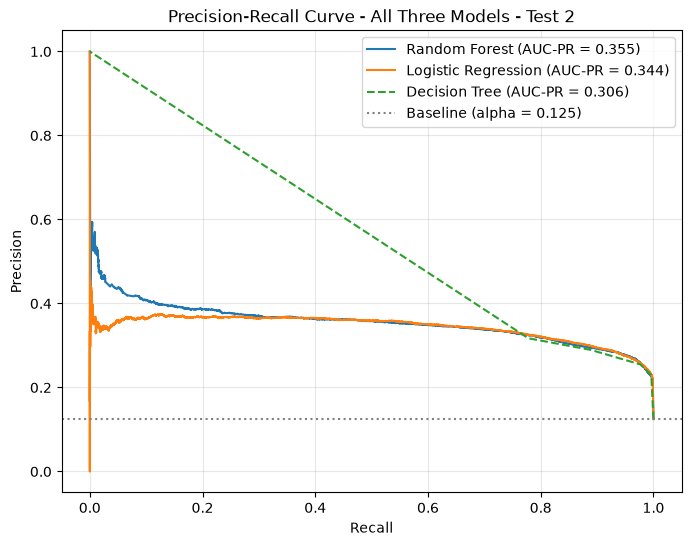

In [51]:
# compute average precision is the area under the pr curve for decision tree
ap_score_dt = average_precision_score(y_test2, y_proba2)
precision_dt, recall_dt, thresholds_dt = precision_recall_curve(y_test2, y_proba2)


# Compute precision-recall curve and average precision for the random forest
precision_rf2, recall_rf2, thresholds_rf2 = precision_recall_curve(y_test2, y_proba_rf2)
ap_score_rf2 = average_precision_score(y_test2, y_proba_rf2)

# Compute precision-recall curve and average precision for the random forest
precision_lr2, recall_lr2, thresholds_lr2 = precision_recall_curve(y_test2, y_proba_lr2)
ap_score_lr2 = average_precision_score(y_test2, y_proba_lr2)

plt.figure(figsize=(8, 6))
plt.plot(recall_rf2, precision_rf2, label=f'Random Forest (AUC-PR = {ap_score_rf2:.3f})')
plt.plot(recall_lr2, precision_lr2, label=f'Logistic Regression (AUC-PR = {ap_score_lr2:.3f})')
plt.plot(recall_dt, precision_dt, label=f'Decision Tree (AUC-PR = {ap_score_dt:.3f})', linestyle='--')

baseline = y_test.mean()
plt.axhline(y=baseline, color='gray', linestyle=':', label=f'Baseline (alpha = {baseline:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - All Three Models - Test 2')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Test 3
Dropping: `Driving_License`,   
Encoded: `Gender`, `Vehicle_Damage`, `Policy_Sales_Channel`, `Vehicle_Age`, `Region_Code'`  
Log Transform: `Annual_Premium`

In [52]:
df3 = insurance_df.copy()

In [53]:
# manual ordinal encoding
df3['Vehicle_Age'] = df3['Vehicle_Age'].map({'< 1 Year': 0, '1-2 Year': 1, '> 2 Years': 2})

# log transformation for Annual_Premium
df3['Annual_Premium_Log'] = np.log1p(df3['Annual_Premium'])

# one dummy encoding
df3 = pd.get_dummies(df3, columns = ['Gender', 'Vehicle_Damage', 'Policy_Sales_Channel', 'Region_Code'], drop_first = True)


In [54]:
df3 = df3.drop(
    columns=['Driving_License', 'Annual_Premium', 'id'])

In [55]:
X = df3.drop(columns=['Response'])
y = df3['Response']

In [56]:
X_train3, X_test3, y_train3, y_test3 = train_test_split( 
    X, y, test_size = 0.2, random_state = 42)

### Decsion Tree

In [57]:
# class_weight 'balanced' reweights the loss so the minority class
dt3= DecisionTreeClassifier(criterion = 'entropy', max_leaf_nodes = 5, class_weight= 'balanced', random_state = 42).fit(X_train3, y_train3)

In [58]:
y_pred3 = dt3.predict(X_test3)

In [59]:
y_proba3 = dt3.predict_proba(X_test3)[:,1]

In [60]:
cm_dt = confusion_matrix(y_test3, y_pred3)
cm_dt_df = pd.DataFrame(
    cm_dt, index=['Actual No', 'Actual Yes'], columns = ['Predicted  No', 'Predicted Yes'])
cm_dt_df

,Predicted No,Predicted Yes
Actual No,45896,20803
Actual Yes,1053,8470


In [61]:
print('Decision Tree')
print('---------------------------------------------------------')
print(classification_report(y_test3, y_pred3))
print('ROC-AUC:', roc_auc_score(y_test3, y_proba3))
print('AUC-PR:', average_precision_score(y_test3, y_proba3))

Decision Tree
---------------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.69      0.81     66699
           1       0.29      0.89      0.44      9523

    accuracy                           0.71     76222
   macro avg       0.63      0.79      0.62     76222
weighted avg       0.89      0.71      0.76     76222

ROC-AUC: 0.8334927375407218
AUC-PR: 0.30626328071891784


In [62]:
#scaling
continuous_features = ['Age', 'Annual_Premium_Log','Vintage']
scaler = StandardScaler()

X_train_scaled3 = X_train3.copy()
X_test_scaled3 = X_test3.copy()

X_train_scaled3[continuous_features] = scaler.fit_transform(X_train3[continuous_features])
X_test_scaled3[continuous_features] = scaler.transform(X_test3[continuous_features])

In [63]:
# fitting logistic regression on scaled features
lr3 =LogisticRegression(class_weight = 'balanced', max_iter = 1000, random_state =42).fit(X_train_scaled3, y_train3)

In [64]:
#prediction 
y_pred_lr3 = lr3.predict(X_test_scaled3)
y_proba_lr3 = lr3.predict_proba(X_test_scaled3)[:,1]

In [65]:
cm_lr3 = confusion_matrix(y_test3, y_pred_lr3)
cm_lr_df = pd.DataFrame(
    cm_lr3, index=['Actual No', 'Actual Yes'], columns = ['Predicted  No', 'Predicted Yes'])
cm_lr_df

,Predicted No,Predicted Yes
Actual No,44072,22627
Actual Yes,608,8915


In [66]:
print('Logistic Regression')
print('---------------------------------------------------------')
print(classification_report(y_test3, y_pred_lr3))
print('ROC-AUC:', roc_auc_score(y_test3, y_proba_lr3))
print('PR-AUC:', average_precision_score(y_test3, y_proba_lr3))

Logistic Regression
---------------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      0.66      0.79     66699
           1       0.28      0.94      0.43      9523

    accuracy                           0.70     76222
   macro avg       0.63      0.80      0.61     76222
weighted avg       0.90      0.70      0.75     76222

ROC-AUC: 0.8512766160349644
PR-AUC: 0.3433484954110627


### Random Forest

In [67]:
# Fit a random forest
n_estimators = 200          
max_depth = 10   
class_weight = 'balanced'  

rf = RandomForestClassifier(
    n_estimators=n_estimators,
    max_depth=max_depth,
    class_weight=class_weight,
    random_state=42,         
    n_jobs=-1                
).fit(X_train3, y_train3)   

In [68]:
# generate predictions 
y_pred_rf3 = rf.predict(X_test3)                  
y_proba_rf3 = rf.predict_proba(X_test3)[:, 1]    

In [69]:
cm_rf3 = confusion_matrix(y_test3, y_pred_rf3)
cm_rf_df = pd.DataFrame(
    cm_rf3, index=['Actual No', 'Actual Yes'], columns = ['Predicted  No', 'Predicted Yes'])
cm_rf_df

,Predicted No,Predicted Yes
Actual No,45135,21564
Actual Yes,768,8755


In [70]:
print('Random Forest')
print('---------------------------------------------------------')
print(classification_report(y_test3, y_pred_rf3))
print("ROC-AUC:", roc_auc_score(y_test3, y_proba_rf3))
print('AUC-PR:', average_precision_score(y_test3, y_proba_rf3))

Random Forest
---------------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.68      0.80     66699
           1       0.29      0.92      0.44      9523

    accuracy                           0.71     76222
   macro avg       0.64      0.80      0.62     76222
weighted avg       0.90      0.71      0.76     76222

ROC-AUC: 0.8502573175248479
AUC-PR: 0.35398360172108145


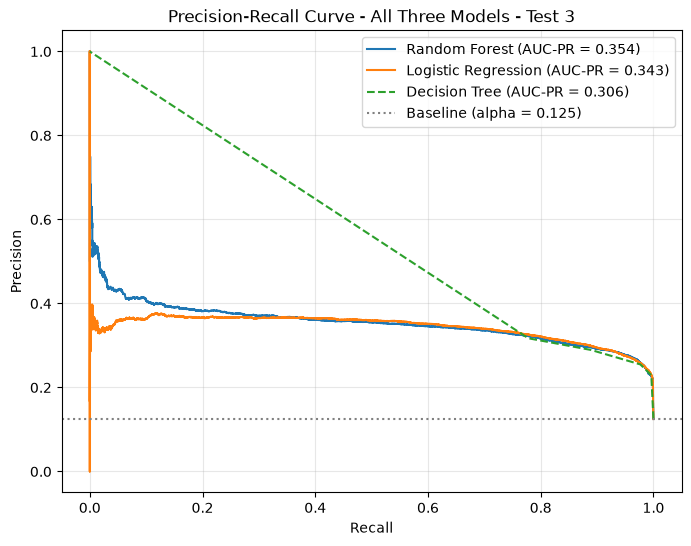

In [71]:
# compute average precision is the area under the pr curve for decision tree
ap_score_dt3 = average_precision_score(y_test3, y_proba3)
precision_dt3, recall_dt3, thresholds_dt3 = precision_recall_curve(y_test3, y_proba3)


# Compute precision-recall curve and average precision for the random forest
precision_rf3, recall_rf3, thresholds_rf3 = precision_recall_curve(y_test3, y_proba_rf3)
ap_score_rf3 = average_precision_score(y_test3, y_proba_rf3)

# Compute precision-recall curve and average precision for the random forest
precision_lr3, recall_lr3, thresholds_lr3 = precision_recall_curve(y_test3, y_proba_lr3)
ap_score_lr3 = average_precision_score(y_test3, y_proba_lr3)

plt.figure(figsize=(8, 6))
plt.plot(recall_rf3, precision_rf3, label=f'Random Forest (AUC-PR = {ap_score_rf3:.3f})')
plt.plot(recall_lr3, precision_lr3, label=f'Logistic Regression (AUC-PR = {ap_score_lr3:.3f})')
plt.plot(recall_dt3, precision_dt3, label=f'Decision Tree (AUC-PR = {ap_score_dt3:.3f})', linestyle='--')

baseline = y_test.mean()
plt.axhline(y=baseline, color='gray', linestyle=':', label=f'Baseline (alpha = {baseline:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - All Three Models - Test 3')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Conclusion
Based on these tests, reducing the number of variables improves the Random Forest's performance. For logistic regression, encoding all categorical variables is required to improve performance. The recommendation is to evaluate the predictive value of each variable using EDA results, assess how each variable affects the model’s performance, and determine which variables are worth retaining.